In the name of God

# **Machine Learning Project: CNN**

Group Members:

Ali Mahdian 

Ali Chegini 

Seyed Mani Mirshabani 810801080

The goal for this part of the project is to develop a neural network to help us translate the information from real world to the previously developed RL model by detecting the position of the robot and obstacles on the board.

To achieve we are going to implement two different methods, we will fine-tune a pre-trained YOLO (You Only Look Once) model for finding the location of the objects and develop a CNN network from scratch.

The issue with developing a CNN from scratch is that networks used for detecting bounding boxes often require a big dataset to be trained on, something we unfortunately don't currently have. To combat this we came up with a clever solution:

* Since the RL model treats the world as a grid and can only instruct the robot to move in these set grids, and since each grid cell cannot be smaller than the size of the robot, we decided to divide the image into smaller sections and instead of training a model for finding the bounding box (and the center of the object), train a model for classification to detect weather the robot (or obstacles) are in a cell or not.

    This approach is somewhat similar to what YOLO does, but the difference is we remove most of the complexity by only training a classifier. This way we should be able to get a decent result with our limited data.

Let us begin the process of developing this costume CNN before fine tuning the YOLO

## 1. Training the CNN

### 1.1. Data Preprocessing

Since we have taken the data manually, we need to do some preprocessing and data augmentation before training the model, which is what we are going to do in this section.

This section is included in the CNN part because we need slightly different method for trining CNN vs YOLO (especially when augmenting the data)

#### 1.1.1. Taking a look at our data

First let's see how many images we have and show a few of them to get an overall idea about what we are working with.

Found 57 images in the 'Raw Images' folder.


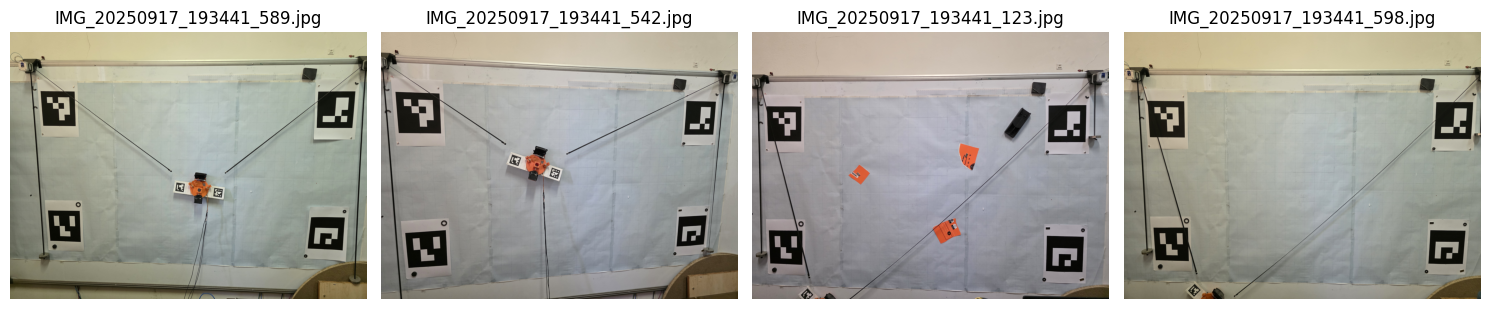

In [1]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_folder = "Raw Images"

image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) 
               if f.endswith(('.jpg', '.jpeg', '.png'))]

print(f"Found {len(image_files)} images in the '{image_folder}' folder.")

random.seed(24)

if len(image_files) >= 4:
    sample_images = random.sample(image_files, 4)
else:
    sample_images = image_files

fig, axes = plt.subplots(1, len(sample_images), figsize=(15, 5))

if len(sample_images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_images):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path))
    ax.axis('off')

plt.tight_layout()
plt.show()

Here we can see the images, as we can see the perspective isn't the same in all of them which is something we are going to fix next. 

Another point to mention is that we have 3 types of images in the dataset, some have the robot in the picture, some have obstacles (the orange pieces of paper and the black object) and some show the empty board. The goal is to be able to distinguish between these three classes.

#### 1.1.2. Fixing the perspective

As our first step we are going to fix the perspective issue using the four markers around the board. We will use the aruco library and open cv to detect them and correct the perspective based on their four corners.

Since we are going to be working with these corrected images a lot, we will save the results in a folder called "Perspective Corrected Images".

##### 1.1.2.1. Detecting the markers

First let's detect the markers and find their ids

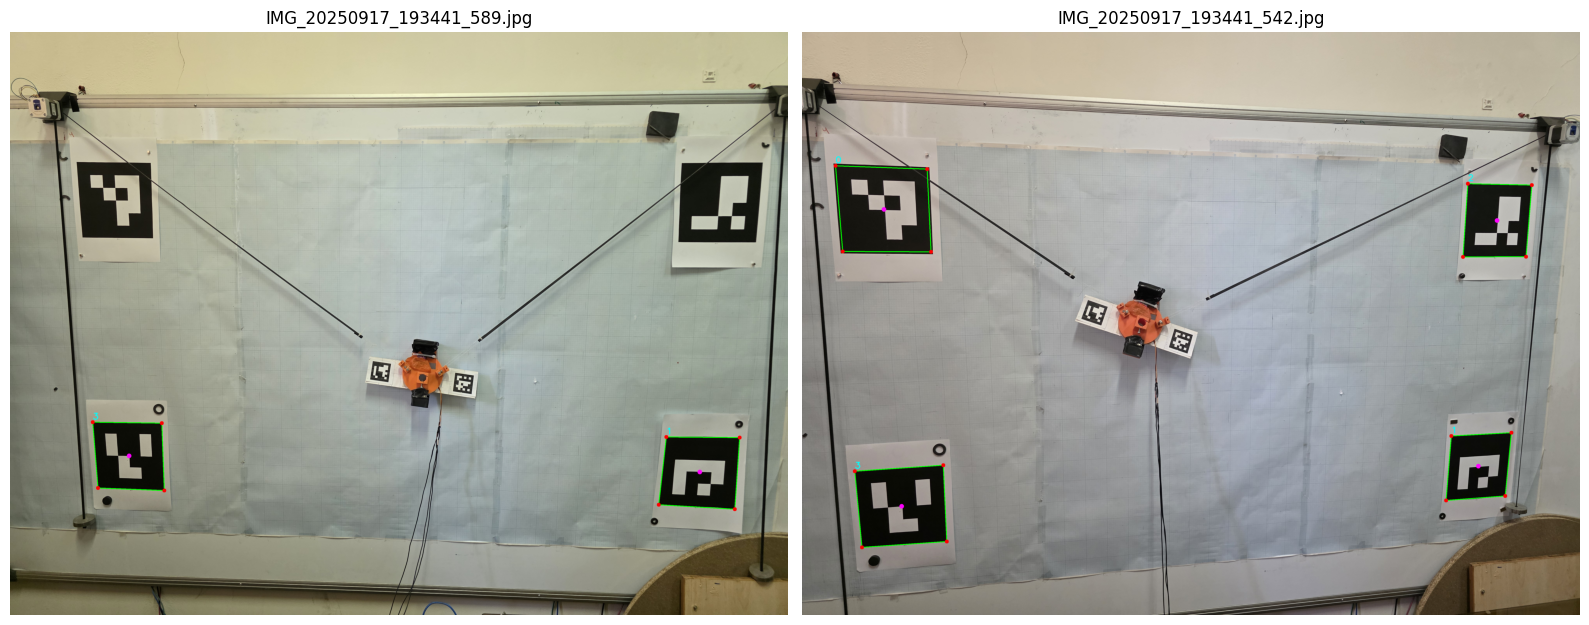

In [2]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt

image_folder = "Raw Images"
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) 
               if f.endswith(('.jpg', '.jpeg', '.png'))]

random.seed(24)
if len(image_files) >= 2:
    sample_images_paths = random.sample(image_files, 2)
else:
    sample_images_paths = image_files

aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
detector_params = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, detector_params)

fig, axes = plt.subplots(1, len(sample_images_paths), figsize=(16, 8))
if len(sample_images_paths) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_images_paths):
    image = cv2.imread(img_path)
    output_image = image.copy()

    corners, ids, rejected = detector.detectMarkers(image)

    if ids is not None:
        for i, marker_id in enumerate(ids):
            marker_corner = corners[i].reshape((4, 2)).astype(int)
            
            cv2.polylines(output_image, [marker_corner], True, (0, 255, 0), thickness=4)

            for point in marker_corner:
                cv2.circle(output_image, tuple(point), 10, (0, 0, 255), -1)

            center = (int(np.mean(marker_corner[:, 0])), int(np.mean(marker_corner[:, 1])))
            cv2.circle(output_image, center, 12, (255, 0, 255), -1)
            
            text_pos = (marker_corner[0][0], marker_corner[0][1] - 15)
            cv2.putText(output_image, str(marker_id[0]), text_pos, 
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 4)
            
    ax.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(img_path))
    ax.axis('off')

plt.tight_layout()
plt.show()

We notice here that some of the markers are not being properly detected, this would cause issues in the future so we will have to find a solution to fix this.

Let's try some methods to resolve this:

Success on downscaled image! Found 4 markers.


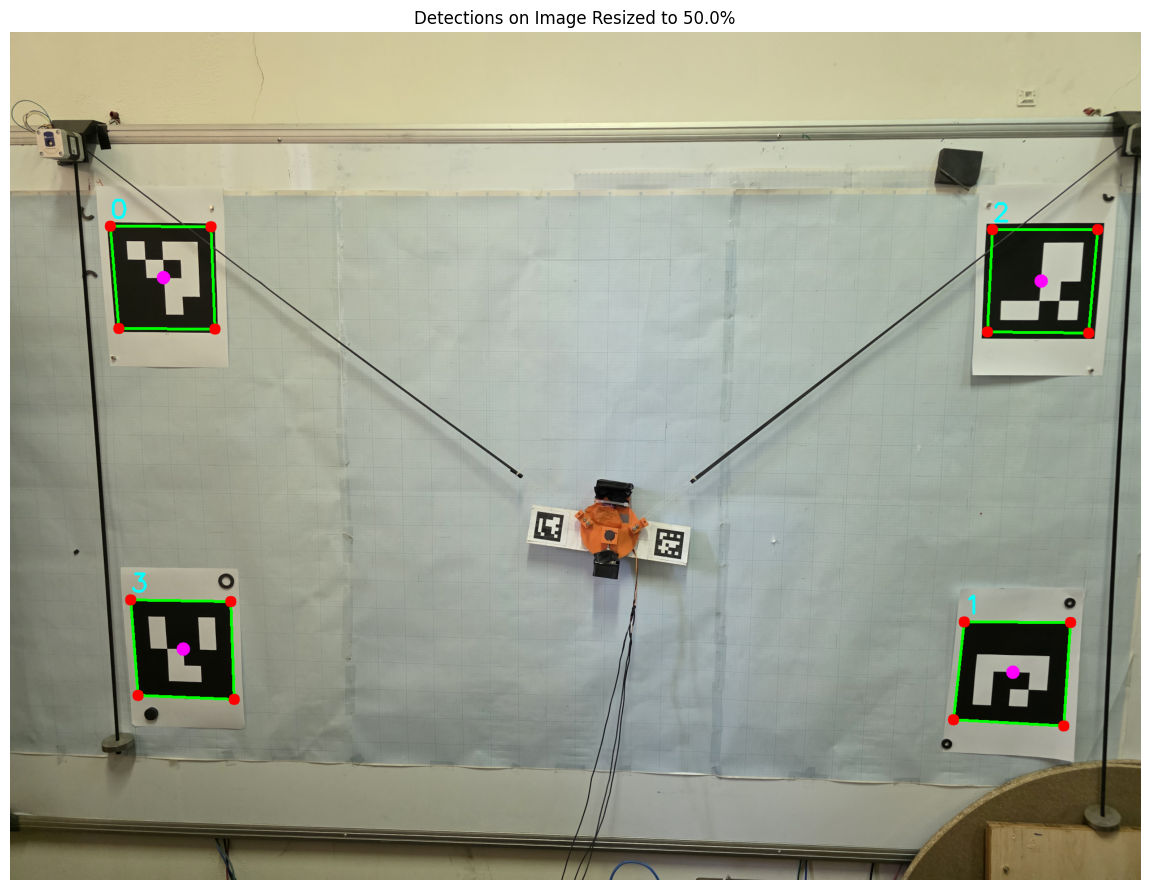

In [3]:
image_folder = "Raw Images"
image_to_test = os.path.join(image_folder, 'IMG_20250917_193441_589.jpg')
if not os.path.exists(image_to_test):
    image_to_test = random.choice(image_files)

aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
params = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, params)

image = cv2.imread(image_to_test)
scale_factor = 0.5
new_width = int(image.shape[1] * scale_factor)
new_height = int(image.shape[0] * scale_factor)

resized_image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)
output_image = resized_image.copy()

corners, ids, rejected = detector.detectMarkers(resized_image)

fig, ax = plt.subplots(1, 1, figsize=(12, 9))

if ids is not None:
    print(f"Success on downscaled image! Found {len(ids)} markers.")
    for i, marker_id in enumerate(ids):
        marker_corner = corners[i].reshape((4, 2)).astype(int)
        cv2.polylines(output_image, [marker_corner], True, (0, 255, 0), thickness=4)
        for point in marker_corner:
            cv2.circle(output_image, tuple(point), 10, (0, 0, 255), -1)
        center = (int(np.mean(marker_corner[:, 0])), int(np.mean(marker_corner[:, 1])))
        cv2.circle(output_image, center, 12, (255, 0, 255), -1)
        text_pos = (marker_corner[0][0], marker_corner[0][1] - 15)
        cv2.putText(output_image, str(marker_id[0]), text_pos,
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 4)
else:
    print("Detection failed on the downscaled image.")

ax.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
ax.set_title(f"Detections on Image Resized to {scale_factor*100}%")
ax.axis('off')

plt.tight_layout()
plt.show()

After some trouble shooting steps, I found out that the high resolution of the camera that was taking the picture was the reason (look at the picture above), as we will need to lower this resolution for our CNN anyways, we will now create another set of images and put them in the "Low Resolution Raw Images"

In [ ]:
import glob

input_folder = "Raw Images"
output_folder = "Low Resolution Raw Images"
scale_factor = 0.2

if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created directory: {output_folder}")

image_paths = glob.glob(os.path.join(input_folder, '*.jpg'))
image_paths.extend(glob.glob(os.path.join(input_folder, '*.png')))
image_paths.extend(glob.glob(os.path.join(input_folder, '*.jpeg')))

processed_count = 0
for img_path in image_paths:
    try:
        image = cv2.imread(img_path)
        if image is None:
            print(f"Warning: Could not read image {os.path.basename(img_path)}. Skipping.")
            continue

        new_width = int(image.shape[1] * scale_factor)
        new_height = int(image.shape[0] * scale_factor)
        
        resized_image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)
        
        base_filename = os.path.basename(img_path)
        output_path = os.path.join(output_folder, base_filename)
        
        cv2.imwrite(output_path, resized_image)
        processed_count += 1
    except Exception as e:
        print(f"Error processing {os.path.basename(img_path)}: {e}")

print(f"\nProcessing complete. Resized and saved {processed_count} images to '{output_folder}'.")

Created directory: Low Resolution Raw Images

Processing complete. Resized and saved 57 images to 'Low Resolution Raw Images'.


Before moving onto the next stage, let's quickly check if we can detect the markers on all the images or not.

Checking 57 images in 'Low Resolution Raw Images'...

❌ Found 1 image(s) where not all 4 markers were detected:


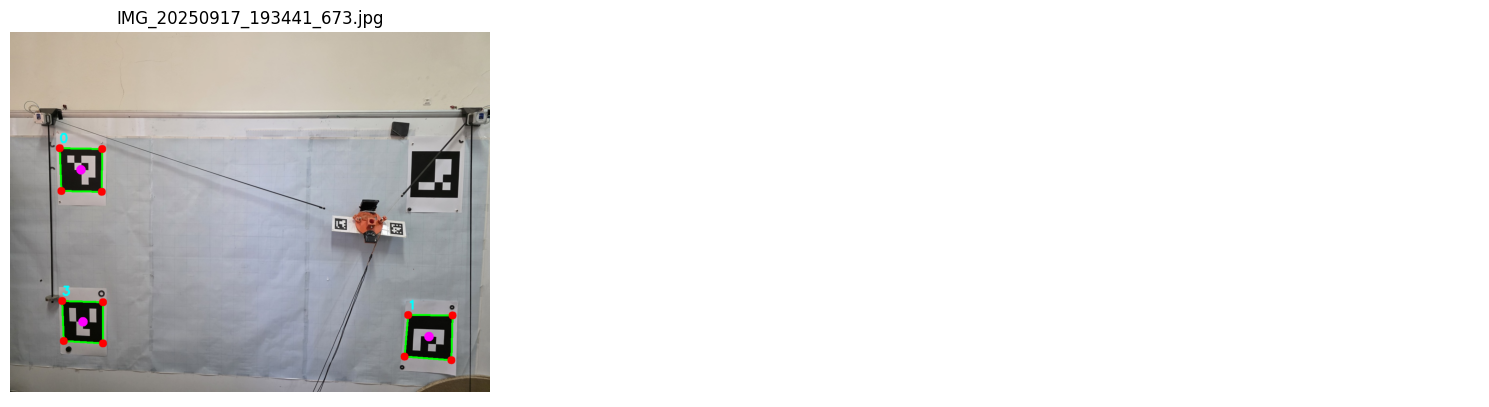

In [5]:
input_folder = "Low Resolution Raw Images"
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
params = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, params)

image_paths = sorted(glob.glob(os.path.join(input_folder, '*.*')))
failed_images_data = []

print(f"Checking {len(image_paths)} images in '{input_folder}'...")

for img_path in image_paths:
    image = cv2.imread(img_path)
    if image is None:
        continue

    corners, ids, _ = detector.detectMarkers(image)
    
    if ids is None or len(ids) != 4:
        failed_images_data.append({'path': img_path, 'corners': corners, 'ids': ids})

if not failed_images_data:
    print("\n✅ Success! All four markers were detected in every image.")
else:
    print(f"\n❌ Found {len(failed_images_data)} image(s) where not all 4 markers were detected:")
    
    num_failed = len(failed_images_data)
    cols = 3
    rows = (num_failed + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = np.array(axes).flatten()

    for i, data in enumerate(failed_images_data):
        image = cv2.imread(data['path'])
        output_image = image.copy()
        ax = axes[i]

        if data['ids'] is not None:
            for j, marker_id in enumerate(data['ids']):
                marker_corner = data['corners'][j].reshape((4, 2)).astype(int)
                cv2.polylines(output_image, [marker_corner], True, (0, 255, 0), thickness=4)
                for point in marker_corner:
                    cv2.circle(output_image, tuple(point), 10, (0, 0, 255), -1)
                center = (int(np.mean(marker_corner[:, 0])), int(np.mean(marker_corner[:, 1])))
                cv2.circle(output_image, center, 12, (255, 0, 255), -1)
                text_pos = (marker_corner[0][0], marker_corner[0][1] - 15)
                cv2.putText(output_image, str(marker_id[0]), text_pos,
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 0), 3)

        ax.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
        ax.set_title(os.path.basename(data['path']))
        ax.axis('off')
    
    for i in range(num_failed, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

##### 1.1.2.1. Detecting the markers